In [6]:
import pandas as pd


In [13]:
df = pd.read_excel(r"C:\Users\Admin\Downloads\SampleSuperstore+dataset (1).xlsx")

In [14]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [16]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [18]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [19]:
df['Month'] = df['Order Date'].dt.month_name()

In [20]:
df['Year'] = df['Order Date'].dt.year

In [22]:
df[['Order Date','Month','Year']].head()

,Order Date,Month,Year
0,2016-11-08,November,2016
1,2016-11-08,November,2016
2,2016-06-12,June,2016
3,2015-10-11,October,2015
4,2015-10-11,October,2015


In [23]:
monthly_sales = df.groupby('Month')['Sales'].sum()

In [24]:
monthly_sales

Month
April        137762.1286
August       159044.0630
December     325293.5035
February      59751.2514
January       94924.8356
July         147238.0970
June         152718.6793
March        205005.4888
May          155028.8117
November     352461.0710
October      200322.9847
September    307649.9457
Name: Sales, dtype: float64

In [25]:
import matplotlib.pyplot as plt

In [26]:
plt.figure(figsize=(12,5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

Text(0, 0.5, 'Sales')

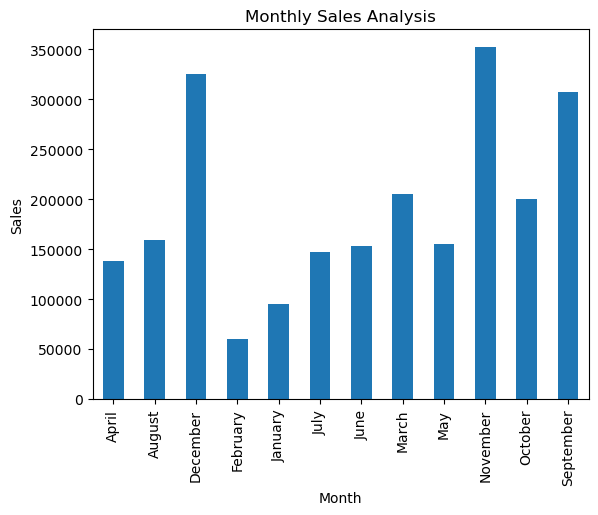

In [28]:
monthly_sales.plot(kind='bar')
plt.title('Monthly Sales Analysis')
plt.xlabel('Month')
plt.ylabel('Sales')

In [32]:
top_Products = (df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10))

In [33]:
top_Products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

In [34]:
plt.figure(figsize=(12,6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'Top 10 selling products')

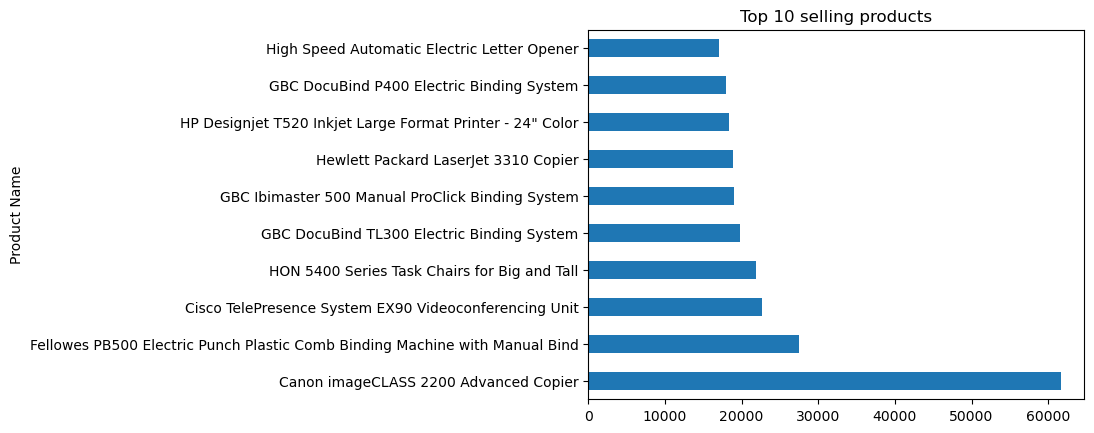

In [36]:
top_Products.plot(kind='barh')
plt.title('Top 10 selling products')

In [38]:
category_sales = (df.groupby('Category')['Sales'].sum())
category_sales

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

Text(0, 0.5, '')

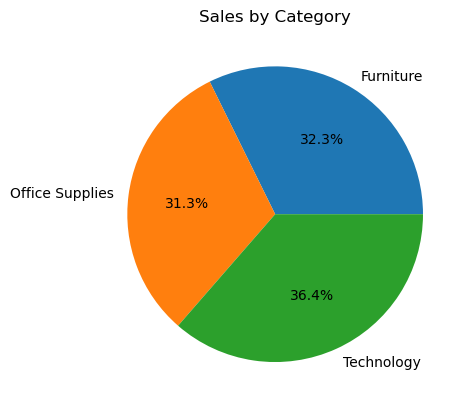

In [42]:
category_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title('Sales by Category')
plt.ylabel('')

In [44]:
category_profit = (df.groupby('Category')['Profit'].sum())
category_profit

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

Text(0.5, 1.0, 'Profit By Category')

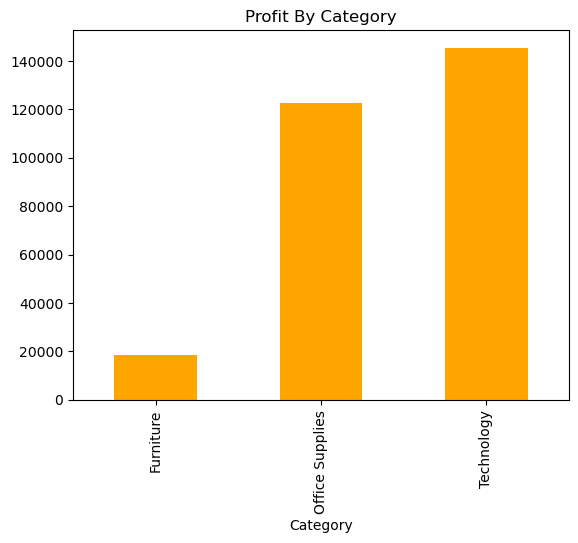

In [45]:
category_profit.plot(kind='bar', color='orange')
plt.title('Profit By Category')

In [47]:
region_sales = (df.groupby('Region')['Sales'].sum())
region_sales

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

Text(0.5, 1.0, 'Sales By Region')

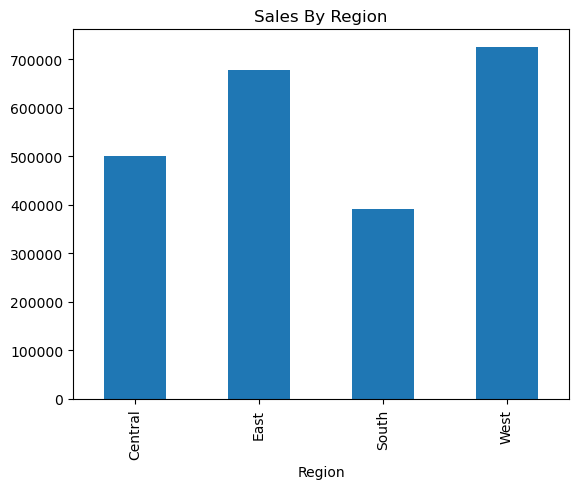

In [48]:
region_sales.plot(kind='bar')
plt.title('Sales By Region')

In [49]:
segment_sales = (df.groupby('Segment')['Sales'].sum())
segment_sales

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

Text(0, 0.5, '')

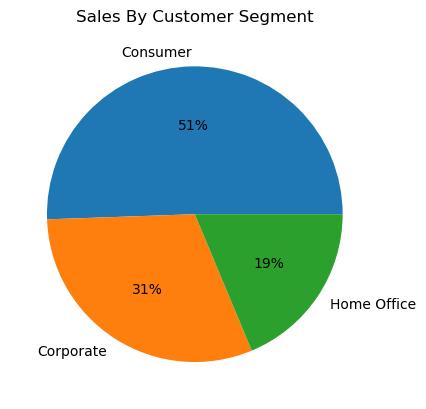

In [53]:
segment_sales.plot(kind='pie',autopct='%1.f%%')
plt.title('Sales By Customer Segment')
plt.ylabel('')

Text(0.5, 1.0, 'Discount vs Profit')

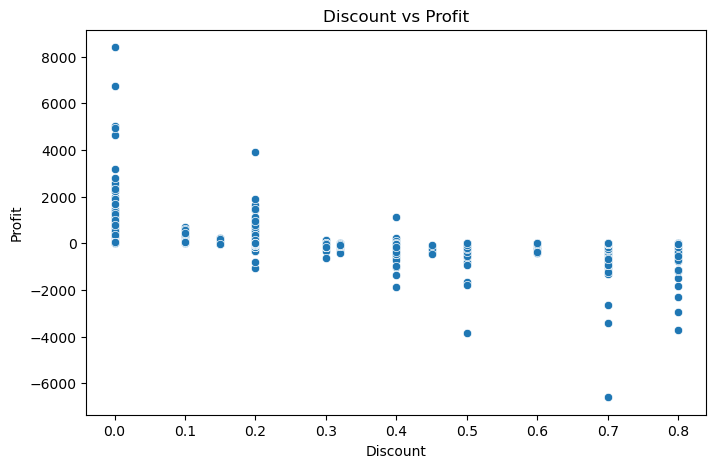

In [55]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.scatterplot(x='Discount',y='Profit', data=df)
plt.title('Discount vs Profit')

<Axes: >

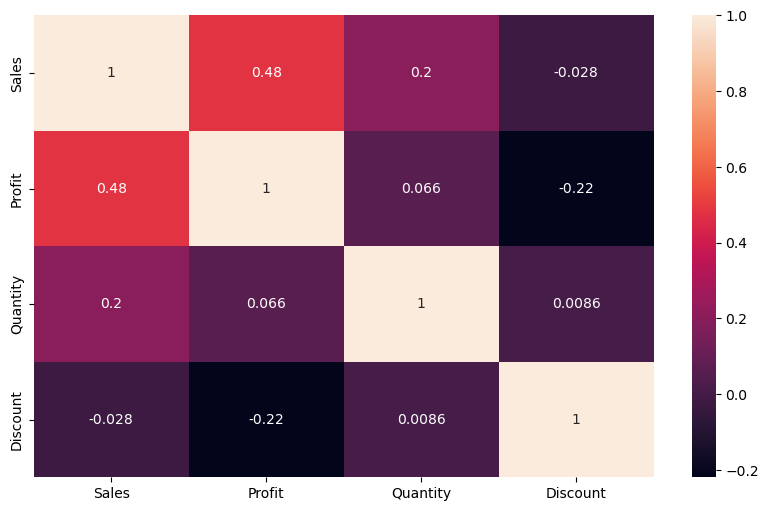

In [56]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['Sales','Profit','Quantity','Discount']].corr(),annot=True)

In [57]:
sales_trend = (df.groupby('Order Date')['Sales'].sum())
sales_trend

Order Date
2014-01-03      16.4480
2014-01-04     288.0600
2014-01-05      19.5360
2014-01-06    4407.1000
2014-01-07      87.1580
                ...    
2017-12-26     814.5940
2017-12-27     177.6360
2017-12-28    1657.3508
2017-12-29    2915.5340
2017-12-30     713.7900
Name: Sales, Length: 1237, dtype: float64

Text(0.5, 1.0, 'Sales Trend Over Time')

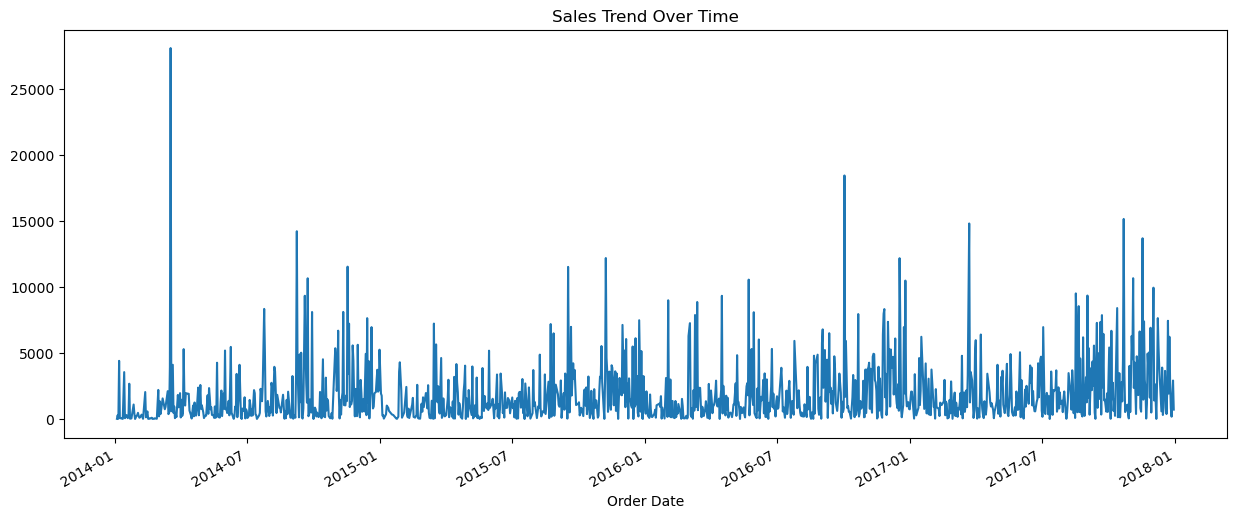

In [58]:
plt.figure(figsize=(15,6))
sales_trend.plot()
plt.title('Sales Trend Over Time')